In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [2]:
import matplotlib.pyplot as plt
from neuroaging.visualization import (
    configure_plotting,
    savefig_nice,
    COL_RAW,
    COL_WEIGHTED,
    COL_REF,
    COL_CENSUS,
    CMAP_RAW,
    CMAP_WEIGHTED,
)

configure_plotting()


2026-01-13 14:46:47.800 | INFO     | neuroaging.config:<module>:11 - PROJ_ROOT path is: /home/groot/Projects/neuroaging


In [3]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
# DATA_DIR = Path("/media/storage/phd/neuroaging/data")
DATA_DIR = Path("/media/groot/Minerva/phd/neuroaging/data")

# Output directory for figures
# OUTPUT_DIR = Path("/media/storage/phd/neuroaging/figures/revision/fig3")
OUTPUT_DIR = Path("/media/groot/Minerva/phd/neuroaging/figures/revision/fig3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [4]:
metrics = ["adc", "gm_vol"]
distribution_metric = "qfmean"

bad_subjects = ["IN120120"]

all_data = {}
for metric in metrics:
    data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
        drop=True
    )
    data = data[~data["subject_code"].isin(bad_subjects)]

    data["age_squared"] = data["age_at_scan"] ** 2
    data["sex"] = data["sex"].map({"M": 0, "F": 1})
    all_data[metric] = data

/tmp/ipykernel_377705/1888622274.py:8: DtypeWarning: Columns (16,22,23,26,32,36,37,38,39,40,42,43,44,45,50,51,52,53,54,55,57,71,73,74,79,80,81,82,89,90,91,101) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
/tmp/ipykernel_377705/1888622274.py:8: DtypeWarning: Columns (1,7,61,67,71,72,73,74,75,77,78,79,80,85,86,87,88,89,90,92,106,108,109,114,115,116,117,118,125,126,127) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(


In [40]:
metric_cols = {metric: "volume" if "vol" in metric else distribution_metric for metric in metrics}

for m, df in all_data.items():
    df = df.rename(columns={metric_cols[m]: "value"})
    all_data[m] = df

In [41]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [42]:
from neuroaging.stats import compute_joint_poststrat_weights

In [43]:
# assign weights
for _, data in all_data.items():
    data["weight"], _ = compute_joint_poststrat_weights(
        data,
        israel_population,
        age_col="age_at_scan",
        sex_col="sex",
        return_bin_table=True,
        cap=10  # Optional: prevents any single female/male from having too much influence
    )

In [46]:
from neuroaging.modeling.regional import fit_regional_models, apply_fdr_correction

from neuroaging.modeling.regional import fit_regional_models, apply_fdr_correction

# Centering option
CENTER_VARIABLES = True

results = {}

for metric, data in all_data.items():
    metric_col = "volume" if metric == "gm_vol" else distribution_metric
    # Set up dataframes to store results
    quad_w, lin_w = parcels.copy(), parcels.copy()

    mean_age = data["age_at_scan"].mean()

    covariates = ["age_c", "C(sex)"]
    if metric == "gm_vol":
        covariates += ["tiv"]
    models = fit_regional_models(
        data,
        parcels,
        region_col=region_col,
        metric_col=metric_col,
        covariates=covariates,
        center_variables=True
    )

    apply_fdr_correction(models)
    results[metric] = models


In [ ]:
from tqdm import tqdm

from neuroaging.modeling.ast import stabilization_age


for metric, data in all_data.items():

    for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
        lin_model = results[metric].linear.loc[i, "model"]
        quad_model = results[metric].quadratic.loc[i, "model"]

        f, p, _ = quad_model.compare_f_test(lin_model)
        delta_aic = quad_model.aic - lin_model.aic
        for results_df, model, is_quadratic in zip(
            [results[metric].linear, results[metric].quadratic],
            [lin_model, quad_model],
            [False, True],
        ):
            # Store the results
            results_df.loc[i, "model"] = model
            results_df.loc[i, "aic"] = model.aic
            results_df.loc[i, "pvalue"] = model.f_pvalue
            results_df.loc[i, "r2"] = model.rsquared
            results_df.loc[i, "r2_adj"] = model.rsquared_adj
            results_df.loc[i, "intercept"] = model.params["Intercept"]
            results_df.loc[i, "t_intercept"] = model.tvalues["Intercept"]
            results_df.loc[i, "pvalue_intercept"] = model.pvalues["Intercept"]
            results_df.loc[i, "beta1"] = model.params["age_c"]
            results_df.loc[i, "se_beta1"] = model.bse["age_c"]
            results_df.loc[i, "t_beta1"] = model.tvalues["age_c"]
            results_df.loc[i, "pvalue_beta1"] = model.pvalues["age_c"]

            if is_quadratic:
                results_df.loc[i, "beta2"] = model.params["I(age_c ** 2)"]
                results_df.loc[i, "se_beta2"] = model.bse["I(age_c ** 2)"]
                results_df.loc[i, "t_beta2"] = model.tvalues["I(age_c ** 2)"]
                results_df.loc[i, "pvalue_beta2"] = model.pvalues["I(age_c ** 2)"]
                beta1, beta2 = (
                    model.params["age_c"],
                    model.params["I(age_c ** 2)"],
                )
                if delta_aic < -15:
                    # We only attempt to find a vertex if the quadratic is significantly better
                    age_star, clipped, u = stabilization_age(
                        metric,
                        {"age": quad_model.params["age_c"], "age_sq": quad_model.params["I(age_c ** 2)"]},
                        mean_age
                    )
                else:
                    # For linear or non-sig models, we default to the start of the lifespan
                    age_star, clipped, u = 18, True, (quad_model.params["I(age_c ** 2)"] > 0)
                results_df.loc[i, "age_star"] = age_star
                results_df.loc[i, "clipped"] = clipped
            else:
                results_df.loc[i, "beta2"] = 0
                results_df.loc[i, "se_beta2"] = 0
                results_df.loc[i, "t_beta2"] = 0
                results_df.loc[i, "pvalue_beta2"] = 1
                results_df.loc[i, "age_star"] = 18
                results_df.loc[i, "clipped"] = True


Fitting models: 100%|██████████| 454/454 [00:02<00:00, 206.91it/s]


In [51]:
import numpy as np
import pandas as pd
import nibabel as nb
from nilearn import surface, datasets
from surfplot import Plot
from matplotlib.colors import TwoSlopeNorm  # nice diverging colours
from neuromaps.datasets import fetch_fslr
from brainspace.datasets import load_parcellation


atlas_img = nib.load(nifti_matlab)

# ---------------------------------------------------------------------
# 2.  FETCH A STANDARD SURFACE  (fsaverage5 = 10k vertices per hemi)
# ---------------------------------------------------------------------
surfaces = fetch_fslr()
lh, rh = surfaces["inflated"]


# ---------------------------------------------------------------------
# 3.  SAMPLE ATLAS VOXELS → SURFACE  (nearest-neighbour so labels stay int)
# ---------------------------------------------------------------------
# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")

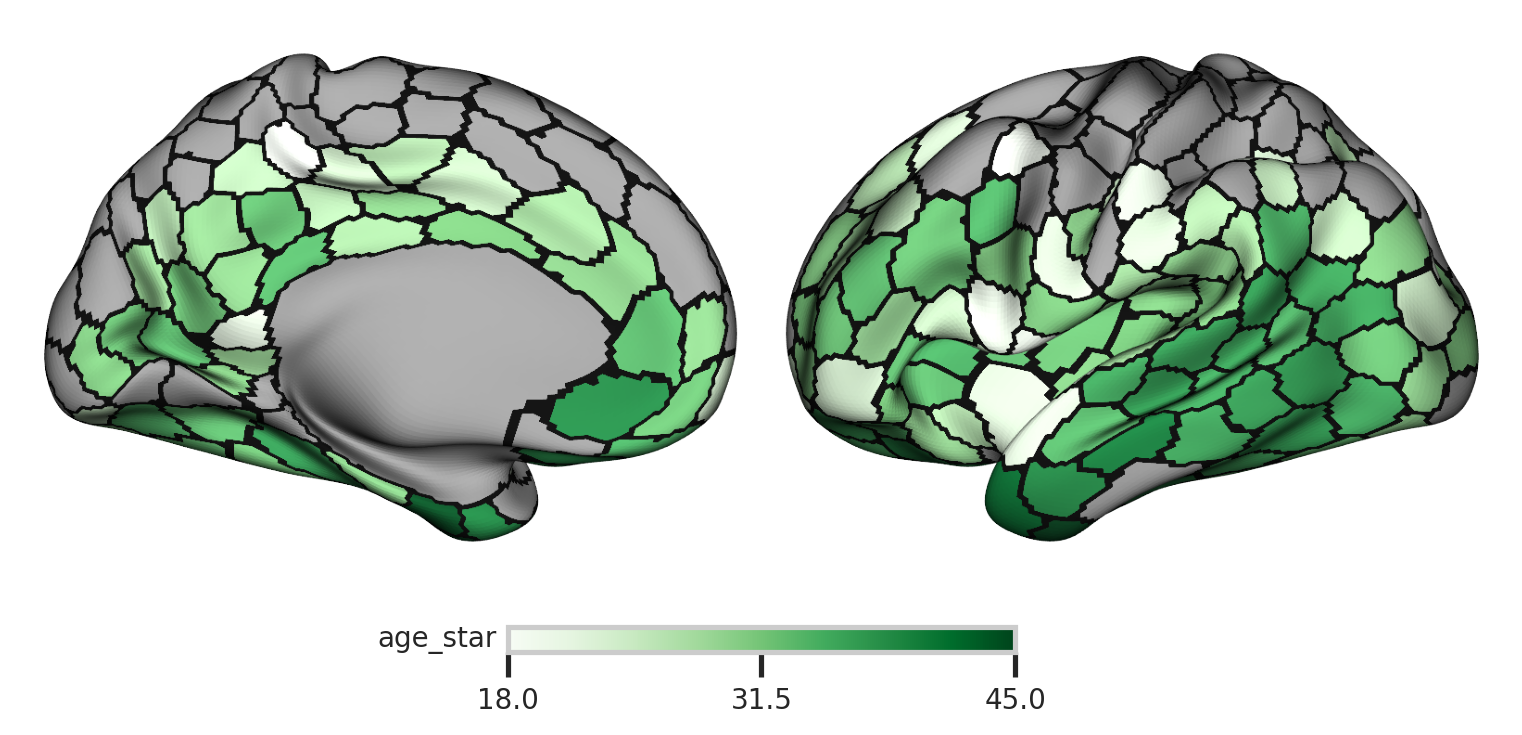

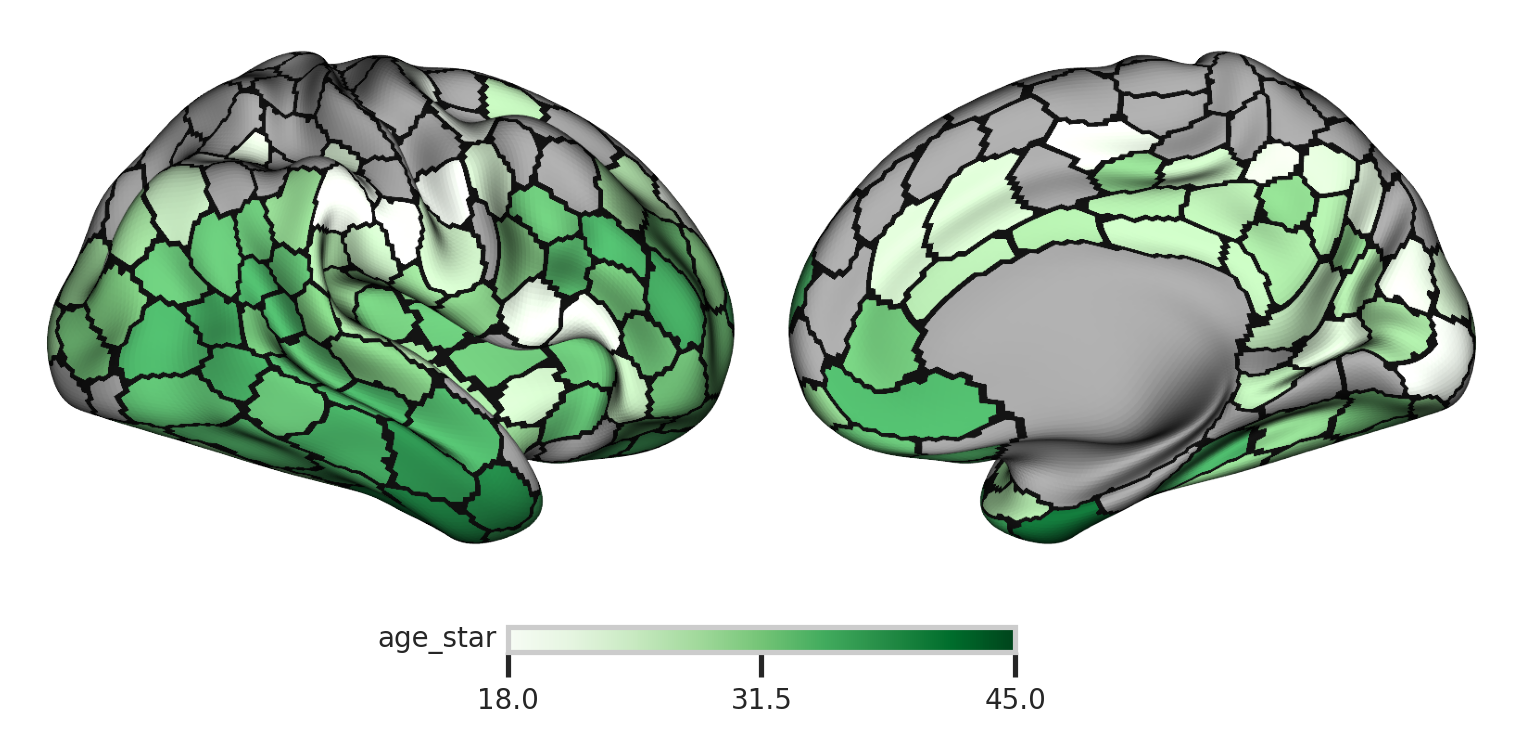

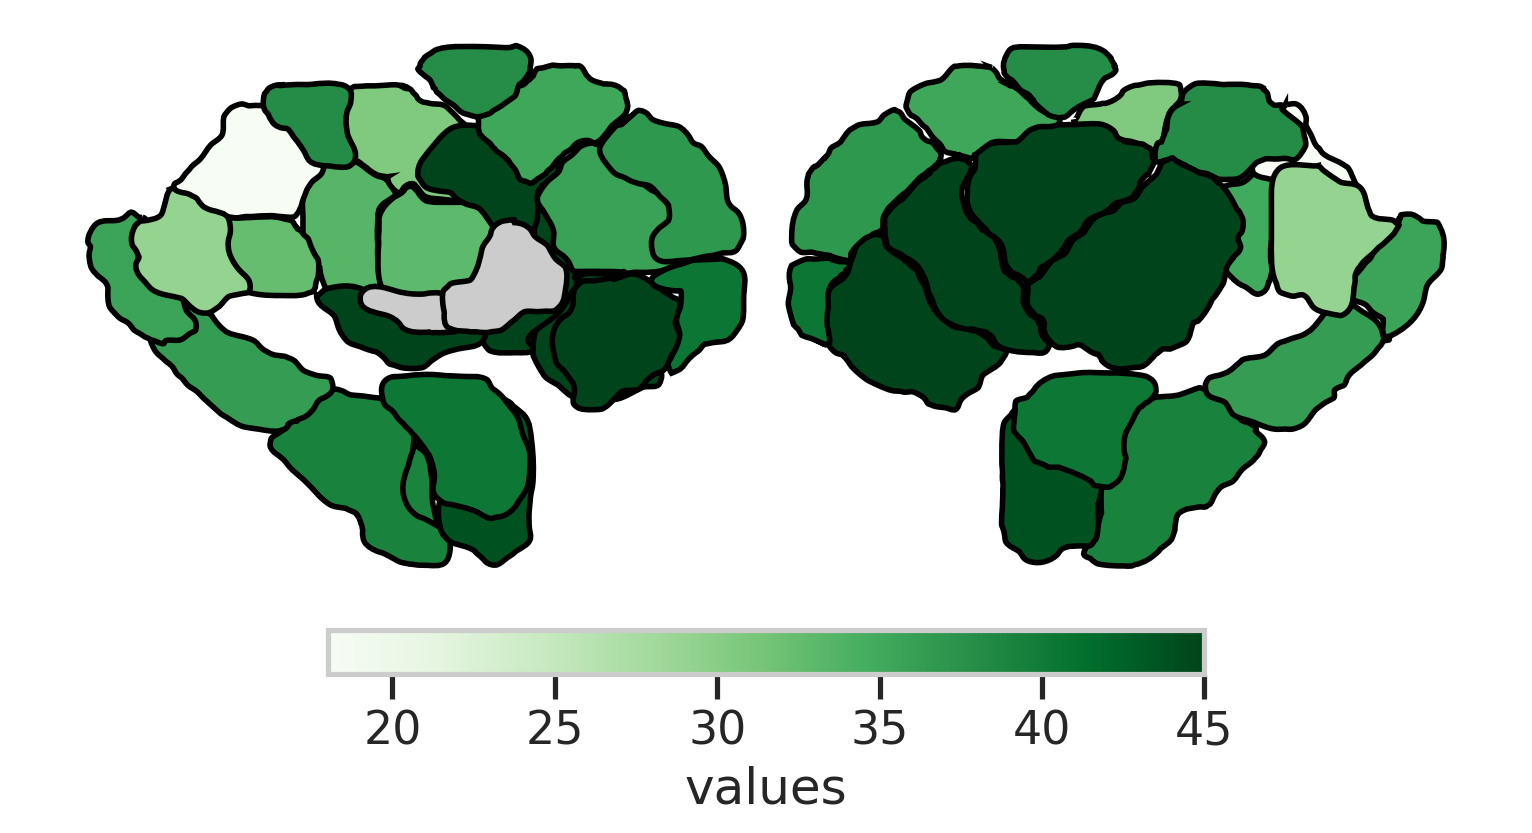

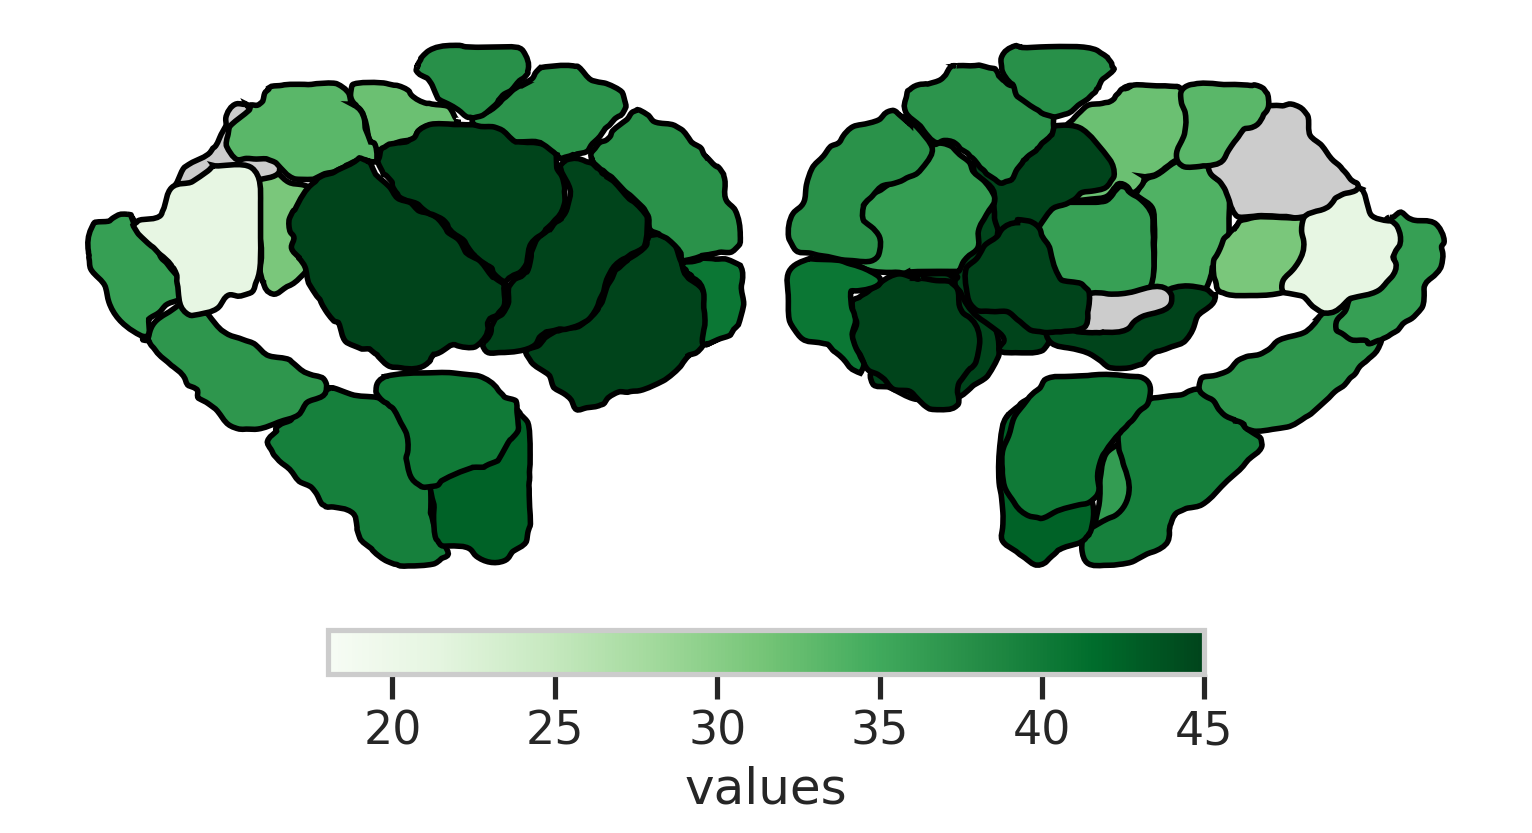

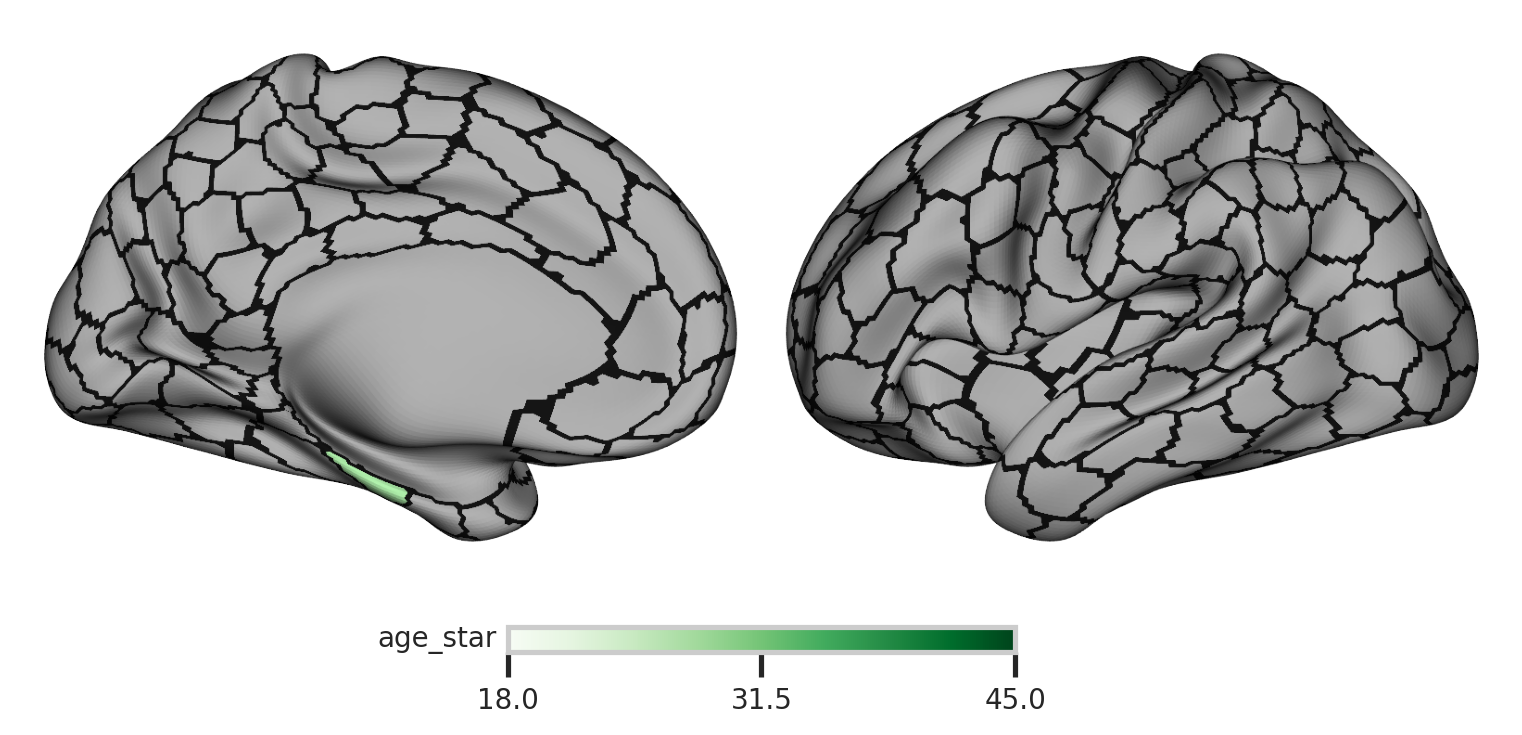

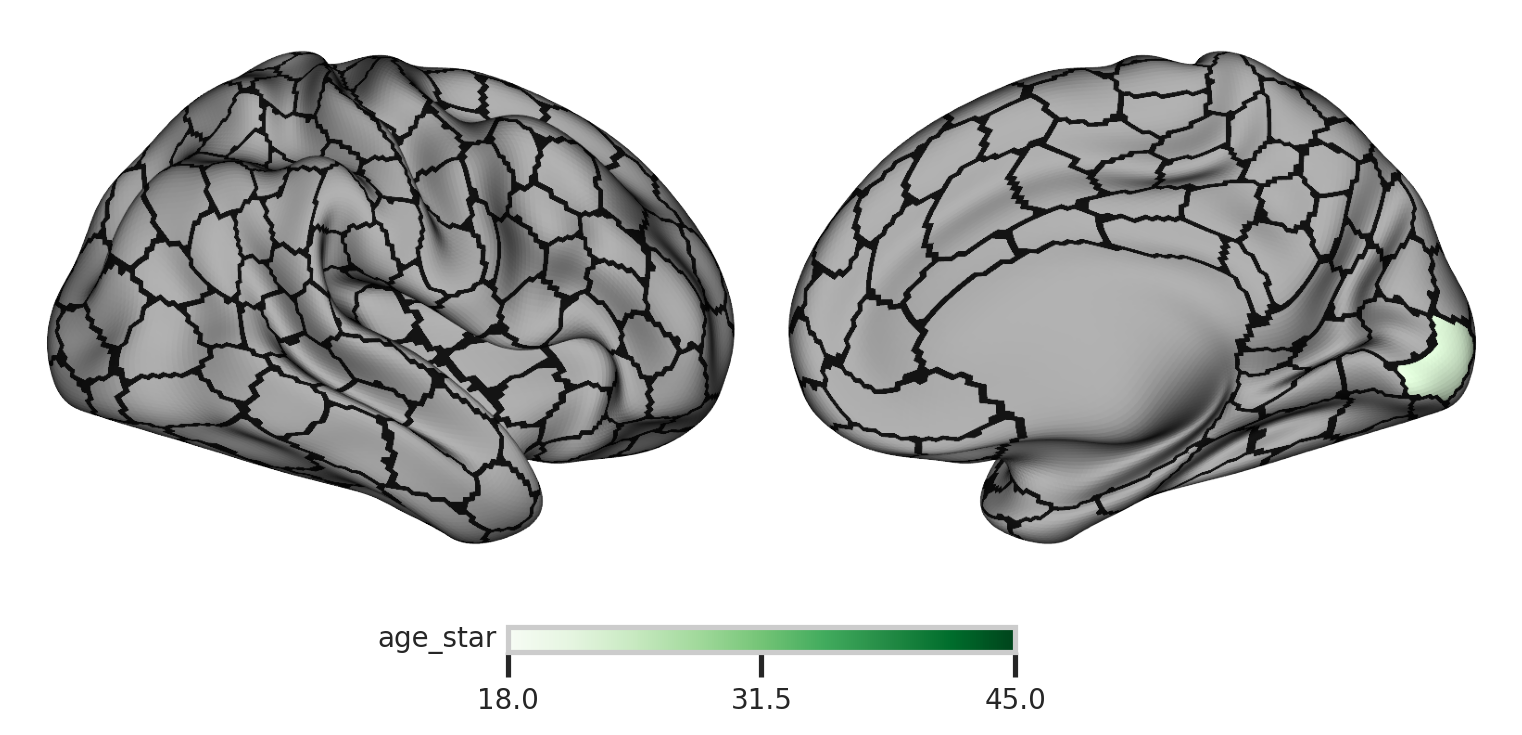

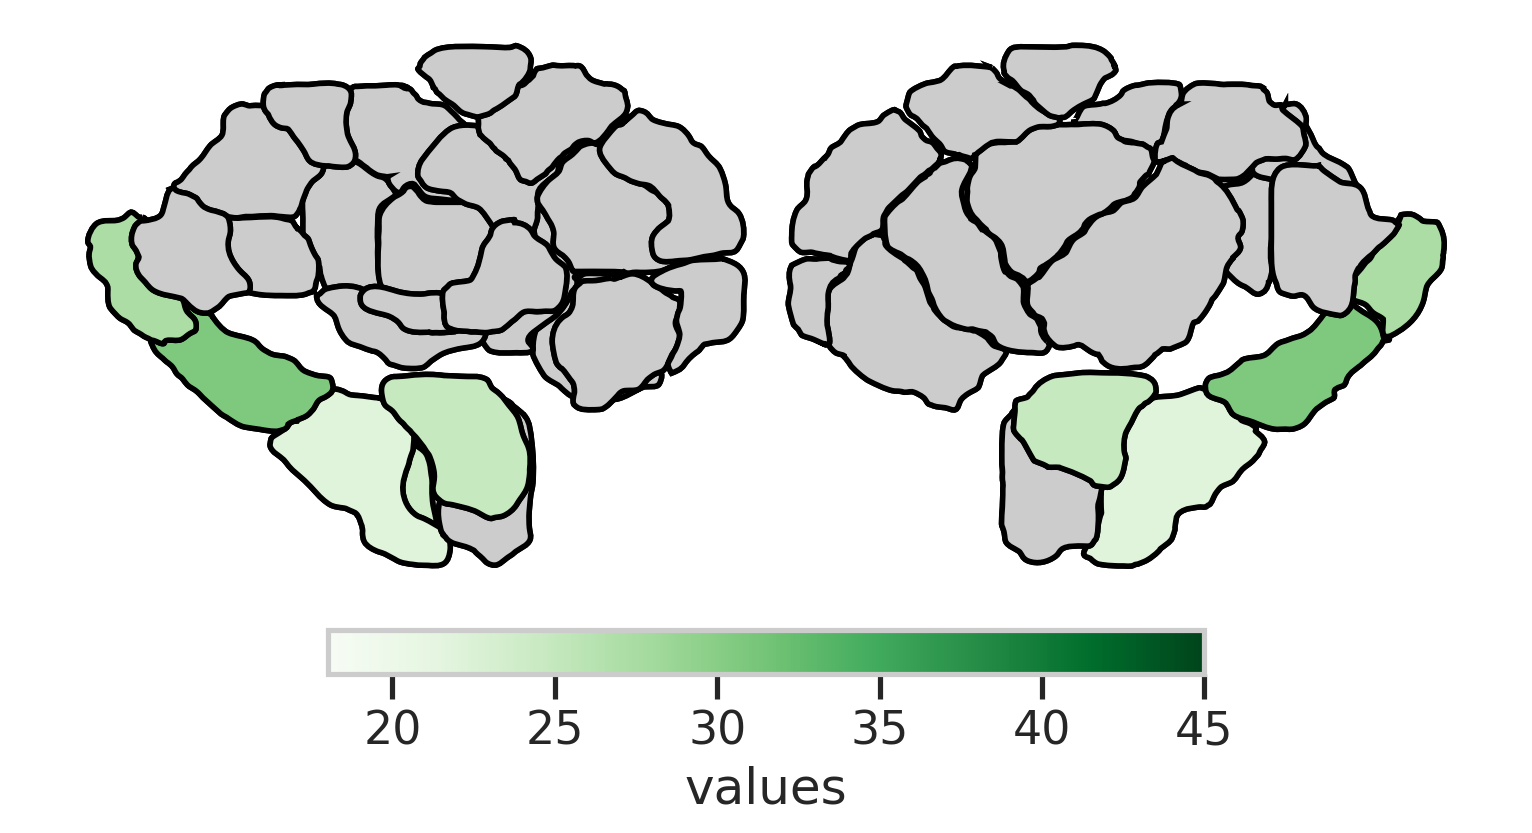

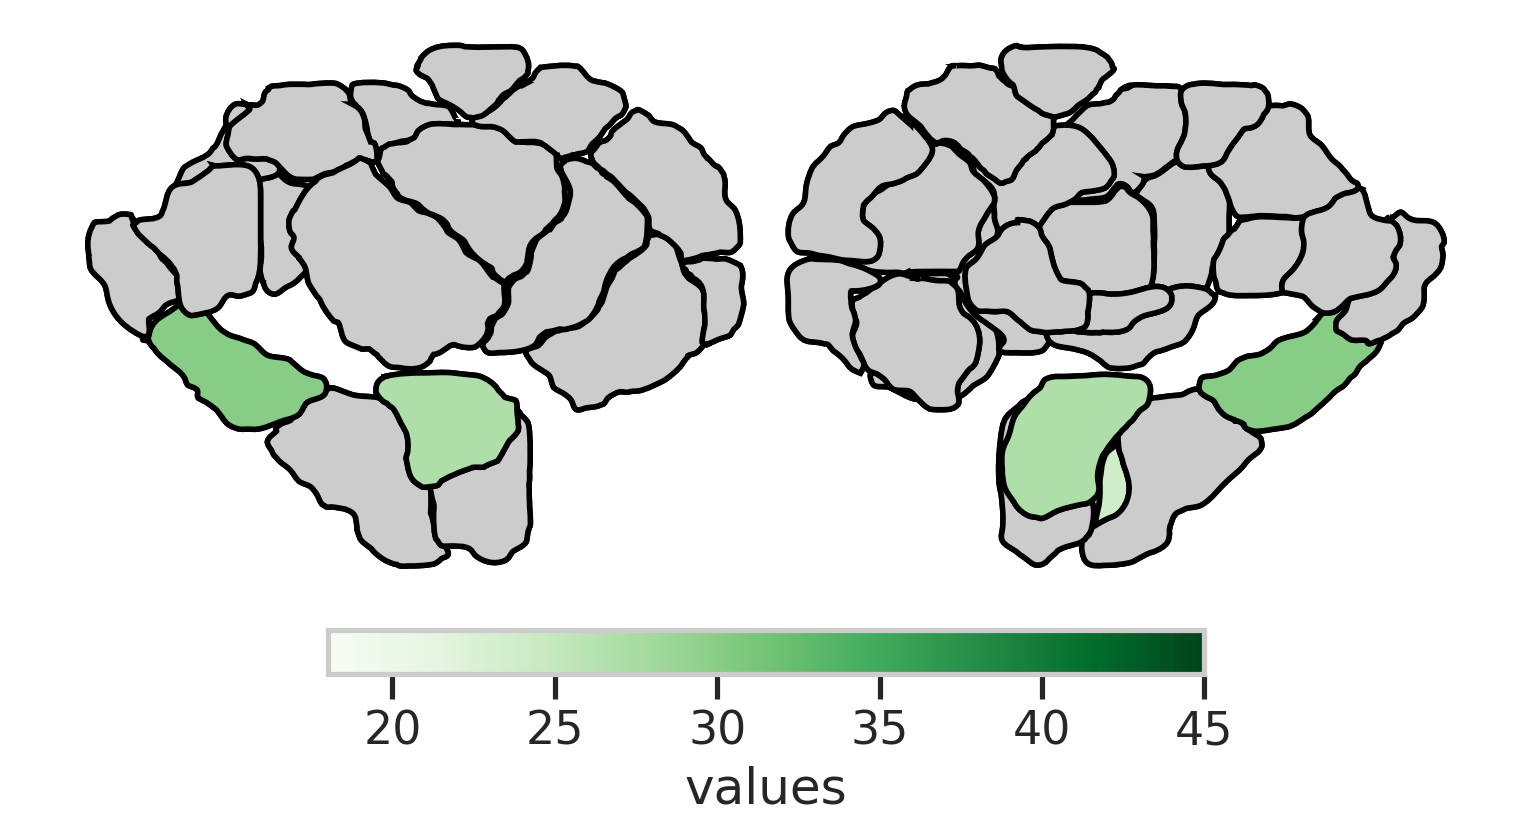

In [52]:
from subcortex_visualization.plotting import plot_subcortical_data
# ---------------------------------------------------------------------
# 4.  MAP REGION IDs → METRIC VALUES
#     vertices with label 0 (background) → NaN so they render transparent
# ---------------------------------------------------------------------
p_threshold = 0.05
value_threshold = 0
vmin = 18
vmax = 45

value_map = {}
value_map_subcortex = {"region": [], "value": [], "Hemisphere": []}

for metric, models in results.items():
    stab_df = models.quadratic
    vis_df = stab_df
    value_column = "age_star"

    value_map_lh = {}  # New: separate map for left hemisphere
    value_map_rh = {}  # New: separate map for right hemisphere

    for i, row in vis_df.iterrows():
        label = row[region_col]
        value = row[value_column]
        hemi_row = row["hemisphere"]  # Get hemisphere from your DataFrame row
        # if (row["p_corrected"] < p_threshold) and (np.abs(row[value_column]) > value_threshold):
        if row["clipped"]:
            value = np.nan
        # else:
        #     value = np.nan
        if "schaefer" in ATLAS:
            if label > int(ATLAS.split("_")[1]):
                value_map_subcortex["region"].append(label)
                value_map_subcortex["value"].append(value)
                value_map_subcortex["Hemisphere"].append(row["hemisphere"])
            else:
                if hemi_row == "L":
                    value_map_lh[label] = value
                elif hemi_row == "R":
                    value_map_rh[label] = value

    # Vectorize mapping for left and right hemispheres separately
    vec_lh = np.vectorize(lambda x: value_map_lh.get(x, np.nan))
    data_lh_mapped = vec_lh(lh_parc)  # Apply LH map to LH parcellation
    vec_rh = np.vectorize(lambda x: value_map_rh.get(x, np.nan))
    data_rh_mapped = vec_rh(rh_parc)  # Apply RH map to RH parcellation

    # Corrected loop for plotting each hemisphere independently
    for hemi_key, hemi_surf_data, mapped_data, parcellation_data in zip(
        ["left", "right"],  # The key for surfplot's dictionary
        [lh, rh],  # The surface object for the current hemisphere
        [data_lh_mapped, data_rh_mapped],  # The mapped data for the current hemisphere
        [lh_parc, rh_parc],  # The parcellation for the current hemisphere
    ):
        # ---------------------------------------------------------------------
        # 5.  BUILD THE PLOT
        # ---------------------------------------------------------------------
        pref_surf = {
            "surf_lh": hemi_surf_data if hemi_key == "left" else None,
            "surf_rh": hemi_surf_data if hemi_key == "right" else None,
        }
        p = Plot(
            **pref_surf,  # Unpack the surface dictionary
            views=(
                ["medial", "lateral"] if hemi_key == "left" else ["lateral", "medial"]
            ),  # Show both medial and lateral for this hemi
            size=(800, 300),  # px; change as needed
            zoom=1.6,
            layout="row",  # For a single hemisphere, row is fine
            mirror_views=False,  # Set to False, as we are plotting one hemi at a time
        )

        # ---- main data layer -------------------------------------------------
        # Pass only the data for the current hemisphere
        # The dictionary now contains only one key-value pair for the current hemisphere
        p.add_layer(
            {hemi_key: mapped_data},
            cmap="Greens",
            color_range=(vmin, vmax),  # Use symmetric range
            # norm=norm,  # Apply the symmetric normalization
            cbar_label=value_column,
            cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
        )
        # ---- outline layer ---------------------------------------------------
        p.add_layer({hemi_key: parcellation_data}, cmap="gray", as_outline=True, cbar=False)

        fig = p.build(
            # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
        )  # Added cbar_kws for better cbar display

        # save figure
        savefig_nice(fig, OUTPUT_DIR / f"fig3_{metric}_{hemi_key}_{value_column}.png", dpi=400)

    subcort_df = pd.DataFrame(value_map_subcortex)
    if "schaefer" in ATLAS:
        subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])


    for hemi in ["L", "R"]:

        fig = plot_subcortical_data(
            subcort_df,
            atlas="Melbourne_S3",
            show_legend=True,
            hemisphere=hemi,
            # cmap="Purples",
            cmap="Greens",
            line_color="black",
            line_thickness=2,
            vmin=vmin,
            vmax=vmax,
            show_figure=False,
        )

        # save figure
        savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)